# BERT separate-QKV and FFN pruning proof

Deterministic visual validation for semantic head/FFN membership, weight-only norms, active states, physical parameter accounting, MAC/BOP coverage, and fake-versus-compact output parity. The pytest suite remains the source of truth.

In [1]:
import copy
import platform

import matplotlib.pyplot as plt
import torch
from fvcore.nn import FlopCountAnalysis
from transformers import BertConfig, BertForQuestionAnswering

from torch_weighttracker import WeightTracker
from torch_weighttracker.calculations import CalcType
from torch_weighttracker.integrations.transformers import bert_pruning_config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
config = BertConfig(vocab_size=101, hidden_size=16, num_hidden_layers=2, num_attention_heads=4, intermediate_size=24, hidden_dropout_prob=0.0, attention_probs_dropout_prob=0.0)
base_model = BertForQuestionAnswering(config).to(device).eval()
inputs = (torch.tensor([[2, 5, 7, 11, 13, 17, 19, 23]], device=device), torch.ones(1, 8, dtype=torch.long, device=device), torch.zeros(1, 8, dtype=torch.long, device=device))
tracker = WeightTracker(base_model, example_inputs=inputs, **bert_pruning_config(base_model))
print({"python": platform.python_version(), "torch": torch.__version__, "device": str(device), "cuda": torch.version.cuda})

/home/mikkel/torch_weighttracker_snapshots/bert_squad_20260722_1745/source/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'python': '3.11.14', 'torch': '2.11.0+cu130', 'device': 'cuda', 'cuda': '13.0'}


In [2]:
names = {module: name for name, module in base_model.named_modules()}
membership = []
for group in tracker.canonical_groups:
    membership.append({"group": group.group_id, "kind": group.unit_kind.value, "units": group.length, "members": [(names[m.module], m.unit_axis.value) for m in group.members]})
membership


[{'group': 0,
  'kind': 'head',
  'units': 4,
  'members': [('bert.encoder.layer.0.attention.self.value', 'out_channel'),
   ('bert.encoder.layer.0.attention.output.dense', 'in_channel'),
   ('bert.encoder.layer.0.attention.self.key', 'out_channel'),
   ('bert.encoder.layer.0.attention.self.query', 'out_channel')]},
 {'group': 1,
  'kind': 'channel',
  'units': 24,
  'members': [('bert.encoder.layer.0.intermediate.dense', 'out_channel'),
   ('bert.encoder.layer.0.output.dense', 'in_channel')]},
 {'group': 2,
  'kind': 'head',
  'units': 4,
  'members': [('bert.encoder.layer.1.attention.self.value', 'out_channel'),
   ('bert.encoder.layer.1.attention.output.dense', 'in_channel'),
   ('bert.encoder.layer.1.attention.self.key', 'out_channel'),
   ('bert.encoder.layer.1.attention.self.query', 'out_channel')]},
 {'group': 3,
  'kind': 'channel',
  'units': 24,
  'members': [('bert.encoder.layer.1.intermediate.dense', 'out_channel'),
   ('bert.encoder.layer.1.output.dense', 'in_channel')]}]

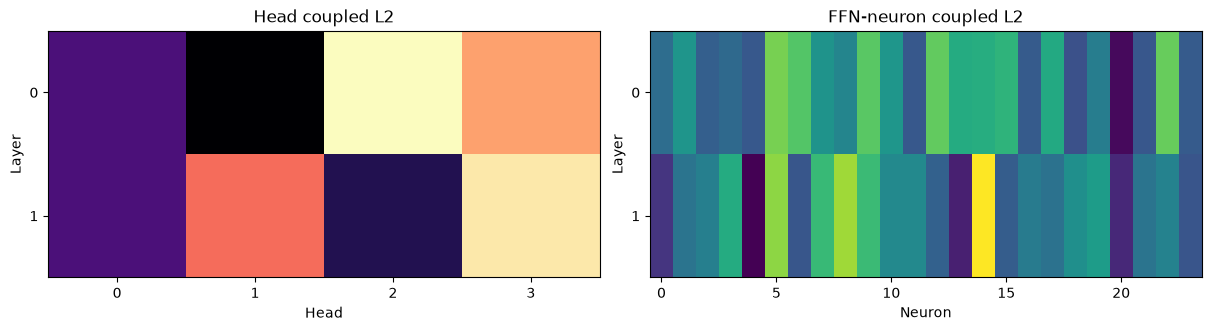

In [3]:
l2 = tracker.get_calculation(CalcType.L2_NORM_PR_UNIT)().detach().float().cpu()
head_l2 = torch.stack((l2[0:4], l2[28:32]))
ffn_l2 = torch.stack((l2[4:28], l2[32:56]))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), constrained_layout=True)
axes[0].imshow(head_l2, aspect="auto", cmap="magma")
axes[0].set(title="Head coupled L2", xlabel="Head", ylabel="Layer", xticks=range(4), yticks=range(2))
axes[1].imshow(ffn_l2, aspect="auto", cmap="viridis")
axes[1].set(title="FFN-neuron coupled L2", xlabel="Neuron", ylabel="Layer", yticks=range(2))
plt.show()

In [4]:
fake_model = copy.deepcopy(base_model)
physical_model = copy.deepcopy(base_model)
fake_tracker = WeightTracker(fake_model, example_inputs=inputs, **bert_pruning_config(fake_model))
physical_tracker = WeightTracker(physical_model, example_inputs=inputs, **bert_pruning_config(physical_model))
before_shapes = {name: tuple(module.weight.shape) for name, module in physical_model.named_modules() if isinstance(module, torch.nn.Linear)}
before_params = sum(parameter.numel() for parameter in physical_model.parameters())
fake_tracker.fake_prune_unit(0, 1)
fake_tracker.fake_prune_unit(1, 2)
summary = fake_tracker.create_tracker("group_pruning_summary").track()["group_pruning_summary"]
active = fake_tracker.get_calculation(CalcType.UNIT_ACTIVE_MASK)().detach().cpu()
physical_tracker.prune_unit(0, 1)
physical_tracker.prune_unit(1, 2)
after_shapes = {name: tuple(module.weight.shape) for name, module in physical_model.named_modules() if isinstance(module, torch.nn.Linear)}
after_params = sum(parameter.numel() for parameter in physical_model.parameters())
print({"head_units": 8, "ffn_units": 48, "summary": summary, "parameter_delta": before_params - after_params})

{'head_units': 8, 'ffn_units': 48, 'summary': {'pruned_units': 2.0, 'pruned_params': 288.0, 'pruned_bias_params': 13.0, 'pruned_physical_params': 301.0, 'groups': {'bert.encoder.layer.0.attention:prune_heads:head': {'pruned_units': 1.0, 'pruned_params': 256.0, 'pruned_bias_params': 12.0, 'pruned_physical_params': 268.0}, 'bert.encoder.layer.0.intermediate.dense:prune_out_channels': {'pruned_units': 1.0, 'pruned_params': 32.0, 'pruned_bias_params': 1.0, 'pruned_physical_params': 33.0}, 'bert.encoder.layer.1.attention:prune_heads:head': {'pruned_units': 0.0, 'pruned_params': 0.0, 'pruned_bias_params': 0.0, 'pruned_physical_params': 0.0}, 'bert.encoder.layer.1.intermediate.dense:prune_out_channels': {'pruned_units': 0.0, 'pruned_params': 0.0, 'pruned_bias_params': 0.0, 'pruned_physical_params': 0.0}}}, 'parameter_delta': 301}


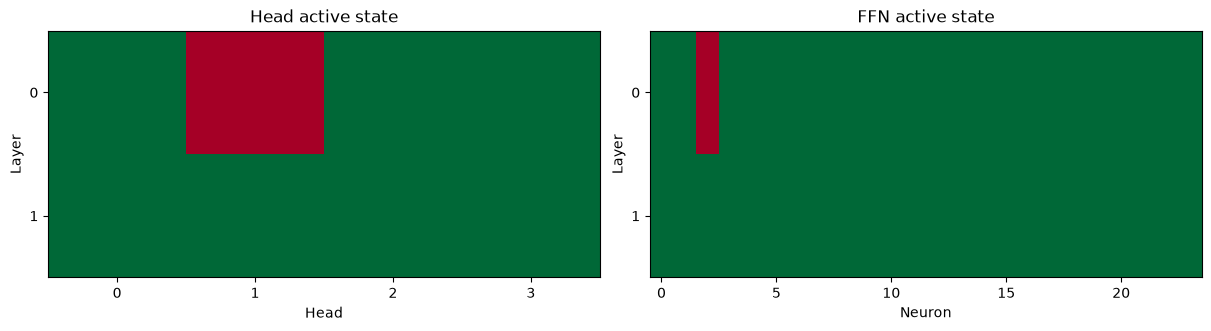

{'bert.encoder.layer.0.attention.self.query': ((16, 16), (12, 16)),
 'bert.encoder.layer.0.attention.self.key': ((16, 16), (12, 16)),
 'bert.encoder.layer.0.attention.self.value': ((16, 16), (12, 16)),
 'bert.encoder.layer.0.attention.output.dense': ((16, 16), (16, 12)),
 'bert.encoder.layer.0.intermediate.dense': ((24, 16), (23, 16)),
 'bert.encoder.layer.0.output.dense': ((16, 24), (16, 23))}

In [5]:
head_active = torch.stack((active[0:4], active[28:32]))
ffn_active = torch.stack((active[4:28], active[32:56]))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), constrained_layout=True)
axes[0].imshow(head_active, aspect="auto", vmin=0, vmax=1, cmap="RdYlGn")
axes[0].set(title="Head active state", xlabel="Head", ylabel="Layer", xticks=range(4), yticks=range(2))
axes[1].imshow(ffn_active, aspect="auto", vmin=0, vmax=1, cmap="RdYlGn")
axes[1].set(title="FFN active state", xlabel="Neuron", ylabel="Layer", yticks=range(2))
plt.show()
shape_changes = {name: (before_shapes[name], shape) for name, shape in after_shapes.items() if before_shapes.get(name) != shape}
shape_changes

In [6]:
with torch.no_grad():
    fake_outputs = fake_model(*inputs)
    compact_outputs = physical_model(*inputs)
start_delta = (fake_outputs.start_logits - compact_outputs.start_logits).abs().max().item()
end_delta = (fake_outputs.end_logits - compact_outputs.end_logits).abs().max().item()
assert start_delta <= 1e-5 and end_delta <= 1e-5
print({"start_logit_max_delta": start_delta, "end_logit_max_delta": end_delta, "parity_atol": 1e-5})

{'start_logit_max_delta': 1.1175870895385742e-08, 'end_logit_max_delta': 5.587935447692871e-09, 'parity_atol': 1e-05}


In [7]:
dense_analysis = FlopCountAnalysis(base_model, inputs).unsupported_ops_warnings(False).uncalled_modules_warnings(False)
compact_analysis = FlopCountAnalysis(physical_model, inputs).unsupported_ops_warnings(False).uncalled_modules_warnings(False)
dense_macs = dense_analysis.total()
compact_macs = compact_analysis.total()
fake_bops = fake_tracker.create_tracker("structured_bops", log_total_bops=True).track()["structured_bops"]
coverage = {"dense_fvcore_macs": dense_macs, "compact_fvcore_macs": compact_macs, "mac_delta": dense_macs - compact_macs, "weighted_layer_bops": fake_bops, "unsupported_ops": {str(key): int(value) for key, value in dense_analysis.unsupported_ops().items()}}
coverage


{'dense_fvcore_macs': 32128,
 'compact_fvcore_macs': 29824,
 'mac_delta': 2304,
 'weighted_layer_bops': {'compression': 0.07964599132537842,
  'bops': 27262976.0,
  'baseline': 29622272.0},
 'unsupported_ops': {'aten::add': 6,
  'aten::embedding': 3,
  'aten::add_': 1,
  'aten::sub': 1,
  'aten::scaled_dot_product_attention': 2,
  'aten::gelu': 2}}

## Interpretation

The structured-BOP value is explicitly a weighted-layer metric. The unsupported-operation table is retained beside it so attention-score matmuls are not silently presented as complete-model BOP accounting.